In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Reduced Order Modeling on Stokes Equations</h1>
<h3 style="margin: 0;  color: #1e1a66">Onine/Offline phases</h3>
</div>

Imports:

In [93]:
import itertools
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial import ConvexHull

import numpy as np
import scipy.sparse.linalg as spla
import scipy.sparse as sp

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.tri as tri
import cmasher as cmr

from Utilities.Mesh_processing import refine
from Utilities.Plot_functions  import (Plot_Initial_Refined_meshes, plot_viscosity, plot_combined_solution, K_matrix_structure, plot_streamlines)
from Solvers.Exchanger_Device  import compute_U_P_solution
from Utilities.Stokes_felib    import calculate_pressure_B

Data:

In [33]:
visc_path  = os.path.join('Reduced_Order_Modeling/No_Online_Offline_phase', 'Data', 'viscosity_snapshots.npz')
basis_path = os.path.join('Reduced_Order_Modeling/Online_Offline_phase',    'Data', 'basis_fields.npz')
sol_path   = os.path.join('Reduced_Order_Modeling/No_Online_Offline_phase', 'Data', 'stokes_solution_snapshots.npz')

for path in [visc_path, basis_path, sol_path]:
    print(f"\nFile: {path}")
    with np.load(path) as data:
        for key in data.files:
            print(f"  Key: {key:<20} Shape: {data[key].shape}")

print("\nAffine operators:")
Affine_Operators = []
for i in range(1, 6):
    path = os.path.join(
        "Reduced_Order_Modeling",
        "Online_Offline_phase",
        "Data",
        f"A{i}.npz"
    )
    A = sp.load_npz(path)
    Affine_Operators.append(A)
    print(f"  A{i:<2} Shape: {A.shape}   nnz: {A.nnz}")


with np.load(visc_path) as data_v:
    v_t_snapshots = data_v['v_t_snapshots']
    parameters    = data_v['parameters']
    knots         = data_v['knots']

with np.load(basis_path) as data_b:
    psi_field=data_b['psi_field']

Affine_Operators = []

for i in range(1, 6):
    path = os.path.join(
        "Reduced_Order_Modeling",
        "Online_Offline_phase",
        "Data",
        f"A{i}.npz"
    )

    Affine_Operators.append(sp.load_npz(path))

with np.load(sol_path) as data_s:
    ux_snapshots = data_s['ux_snapshots']
    uy_snapshots = data_s['uy_snapshots']
    p_snapshots  = data_s['p_snapshots']



File: Reduced_Order_Modeling/No_Online_Offline_phase/Data/viscosity_snapshots.npz
  Key: v_t_snapshots        Shape: (100, 191488)
  Key: parameters           Shape: (100, 5)
  Key: knots                Shape: (5, 2)
  Key: p_fine               Shape: (96817, 2)
  Key: t_fine               Shape: (191488, 7)
  Key: e_fine               Shape: (288304, 3)

File: Reduced_Order_Modeling/Online_Offline_phase/Data/basis_fields.npz
  Key: psi_field            Shape: (191488, 5)
  Key: knots                Shape: (5, 2)
  Key: p_fine               Shape: (96817, 2)
  Key: e_fine               Shape: (288304, 3)
  Key: t_fine               Shape: (191488, 7)

File: Reduced_Order_Modeling/No_Online_Offline_phase/Data/stokes_solution_snapshots.npz
  Key: ux_snapshots         Shape: (100, 96817)
  Key: uy_snapshots         Shape: (100, 96817)
  Key: p_snapshots          Shape: (100, 24473)
  Key: parameters           Shape: (100, 5)
  Key: p_fine               Shape: (96817, 2)
  Key: t_fine    

---

<div style="background-color: #bee7ff; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0;  color: #1e1a66">Mesh</h3>
</div>

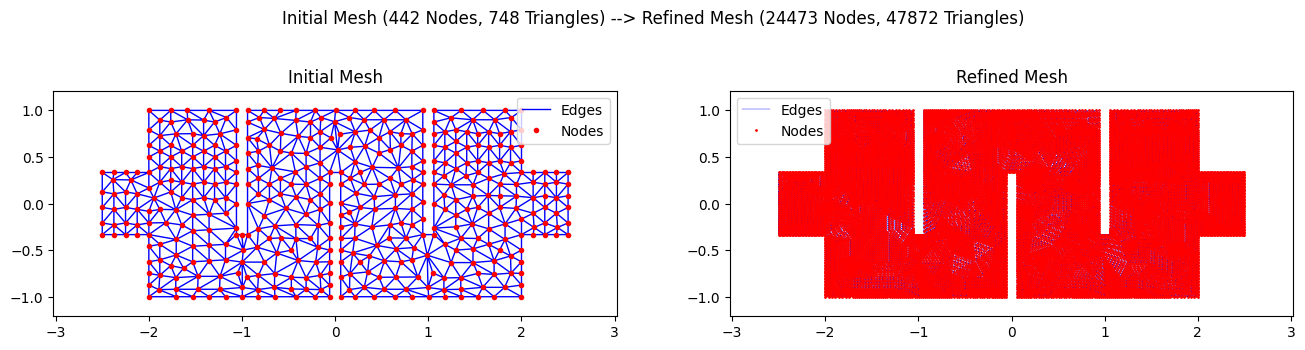

In [4]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/exchanger_device_altered_mesh_data.npz', num_of_refinements=3, 
                                                           plot=True,
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

<div style="background-color: #bee7ff; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0;  color: #1e1a66">Viscosity Parameters</h3>
</div>

The precomputed basis functions visualization $\{\psi_i\}^5_{i=1}$:

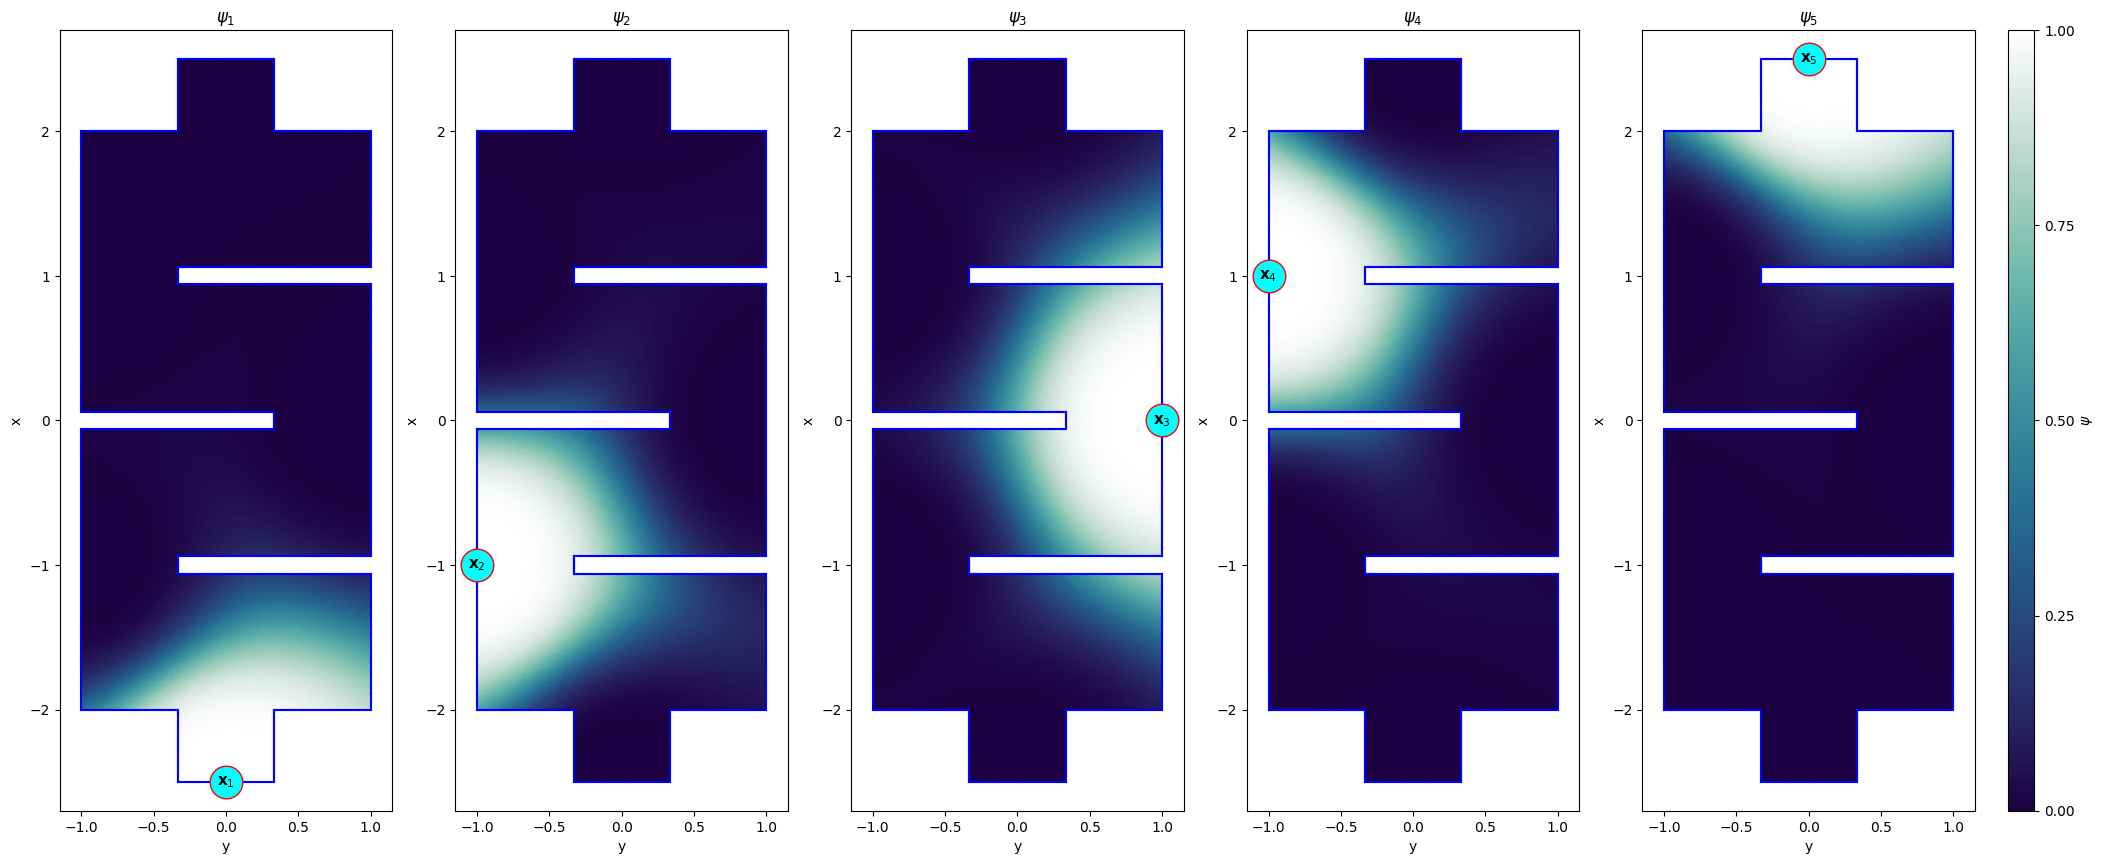

In [5]:
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(22, 9))
savetype = 'png'
# psi1, psi2, psi3, psi4, psi5 = psi_field[:, :5].T

triangulation = tri.Triangulation(
        p_fine[:, 1],
        p_fine[:, 0],
        t_fine[:, :3]
    )

flag1_mask = (e_coarse[:, -1] == 1)
boundary_edges = e_coarse[flag1_mask, :2].astype(int)
x_coords = p_coarse[boundary_edges, 0].T
y_coords = p_coarse[boundary_edges, 1].T

vmin = psi_field[:, :5].min()
vmax = psi_field[:, :5].max()

for i, psi in enumerate(psi_field[:, :5].T):

    im = ax[i].tripcolor(
                triangulation,
                cmap=cmr.ocean,
                facecolors=psi,
                vmin=vmin,
                vmax=vmax,
                shading='flat',
                zorder = 0)
    
    ax[i].plot(y_coords, x_coords, color='b', linewidth=1.5, label='Boundary')

    ax[i].scatter(knots[i, 1], knots[i, 0], 
                      s=550, c='cyan', edgecolors='r', linewidths=1,
                      zorder = 3)
    
    ax[i].text(knots[i, 1], knots[i, 0], 
                s=fr"$\mathbf{{x}}_{{{i + 1}}}$",
                ha='center', va='center',
                fontsize=11,
                zorder=5)
    
    ax[i].set_ylim(-2.70, 2.70)
    ax[i].set_xlim(-1.15, 1.15)
    ax[i].set_ylabel('x')
    ax[i].set_xlabel('y')
    ax[i].set_aspect('equal')

    ax[i].set_title(fr"$\psi_{{{i + 1}}}$")    

plt.tight_layout()

plt.subplots_adjust(right=0.90, wspace=0.19)

fig.canvas.draw()
pos = ax[-1].get_position()
cax = fig.add_axes([pos.x1 + 0.015, pos.y0, 0.012, pos.height])
ticks = np.linspace(vmin, vmax, 5)
cb = fig.colorbar(im, cax=cax, label=r'$\psi$', ticks=ticks)
cb.ax.set_yticklabels([f'{val:.2f}' for val in ticks])
    
plt.savefig(f'Outputs/Viscosity_Basis_Functions.{savetype}', bbox_inches='tight')
plt.show()


In [6]:
viscosity_snapshot_indices = [3, 7, 9]

Full Precomputed VS Basis Reconstructed Viscosity Field :

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Snapshot 3
Maximum absolute error : 1.137e-13
Relative L2 error      : 1.451e-16

Original viscosity, mu = [173.58813481  75.21239864 150.52020575 147.89878161  89.01056842]


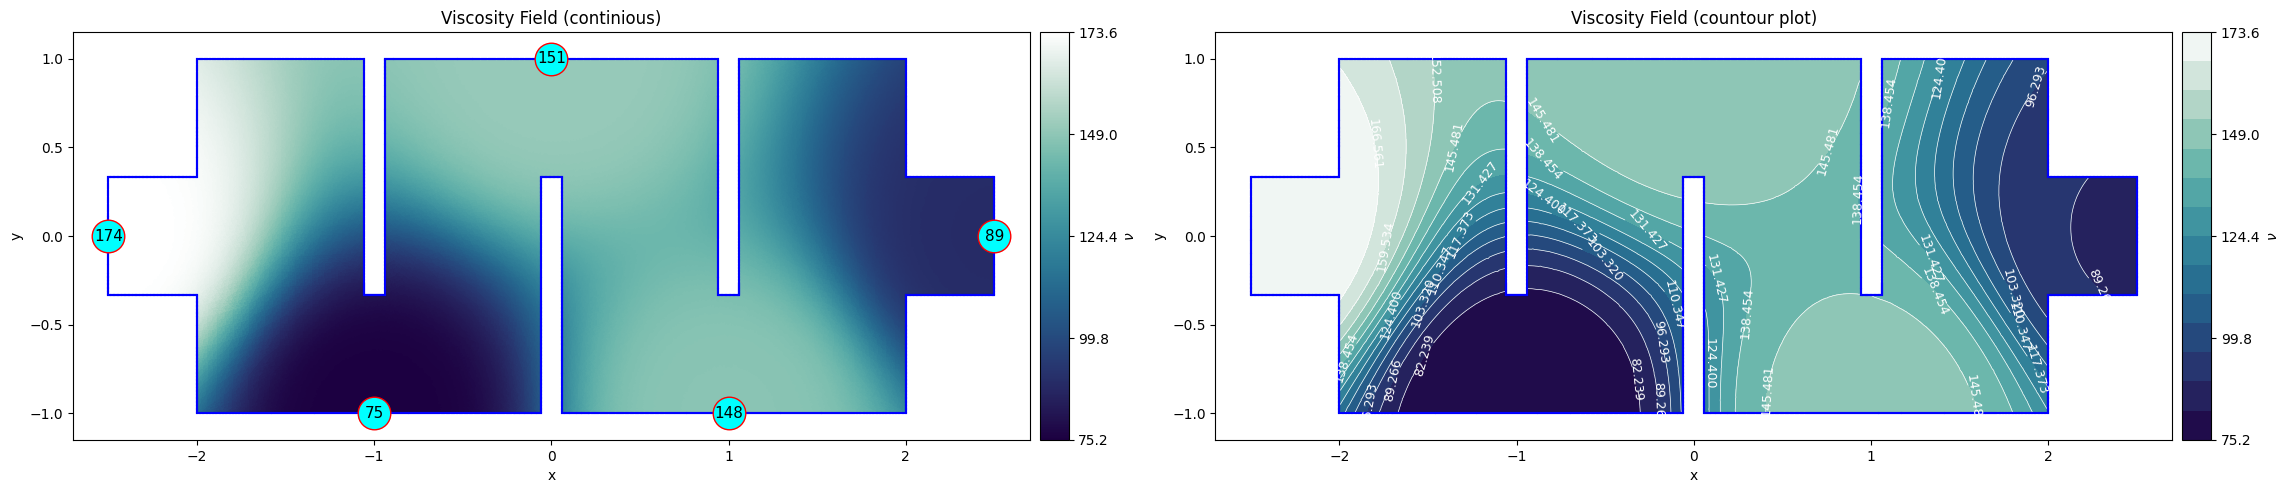


Reconstructed viscosity, mu = [173.58813481  75.21239864 150.52020575 147.89878161  89.01056842]


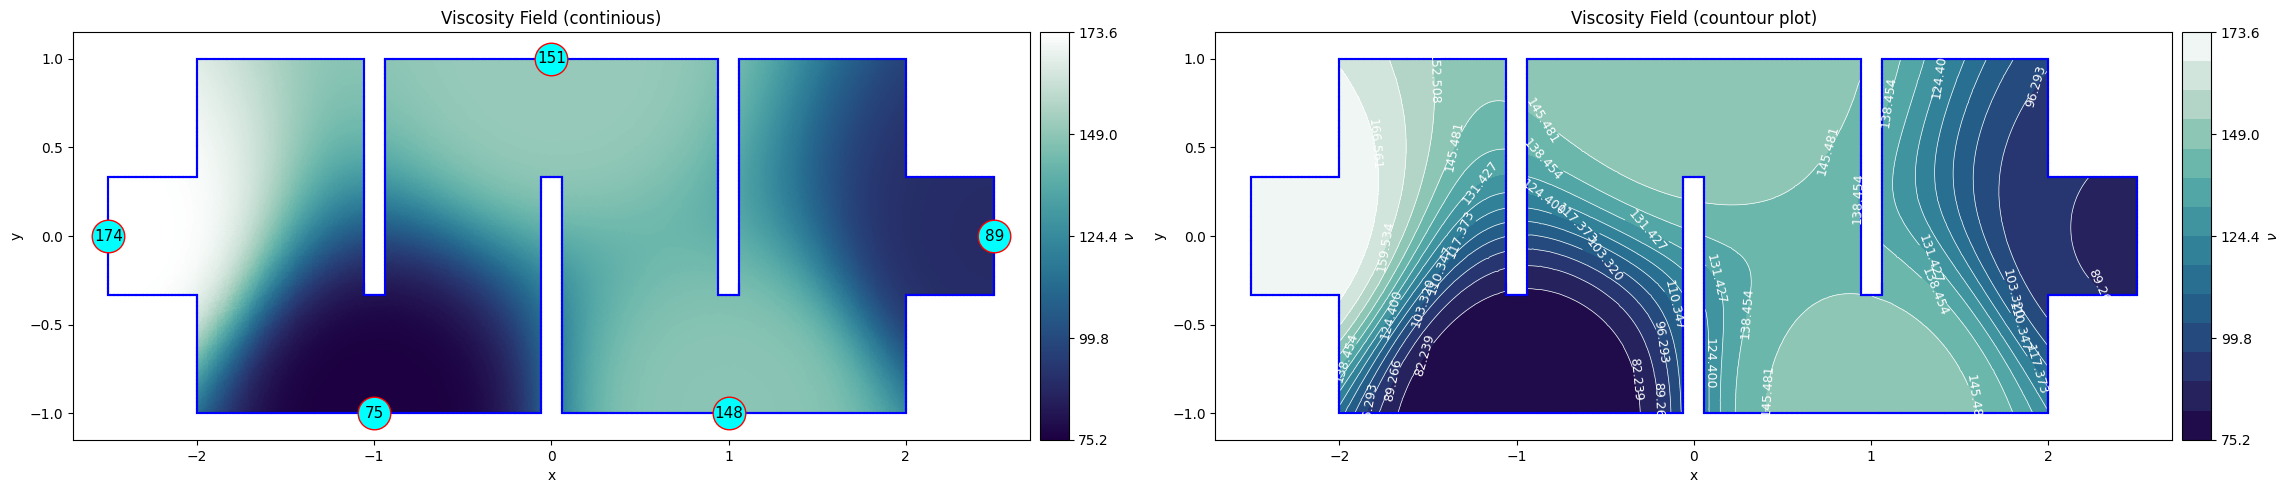

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Snapshot 7
Maximum absolute error : 1.137e-13
Relative L2 error      : 1.415e-16

Original viscosity, mu = [187.53795761 103.60400406 122.36825821  26.22937482  13.59481325]


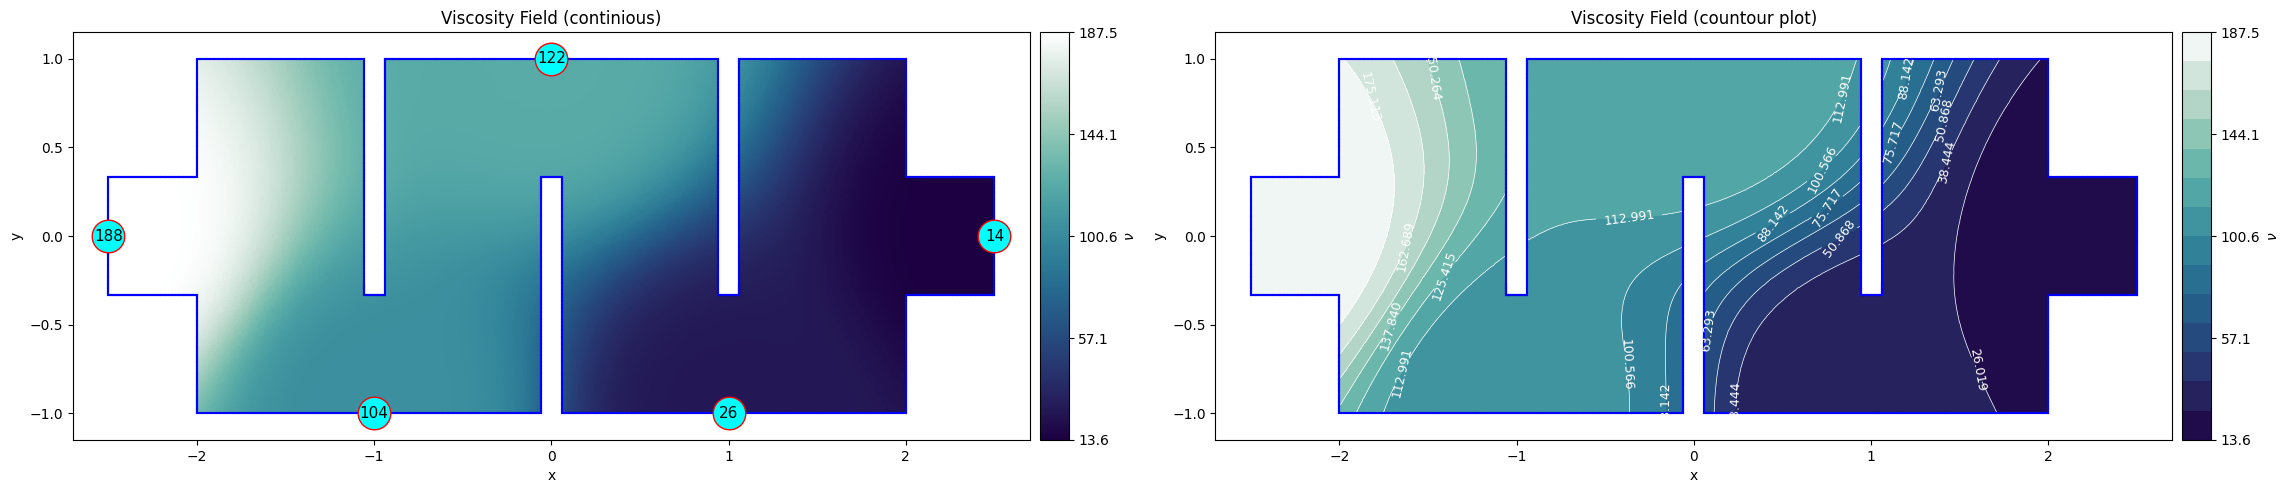


Reconstructed viscosity, mu = [187.53795761 103.60400406 122.36825821  26.22937482  13.59481325]


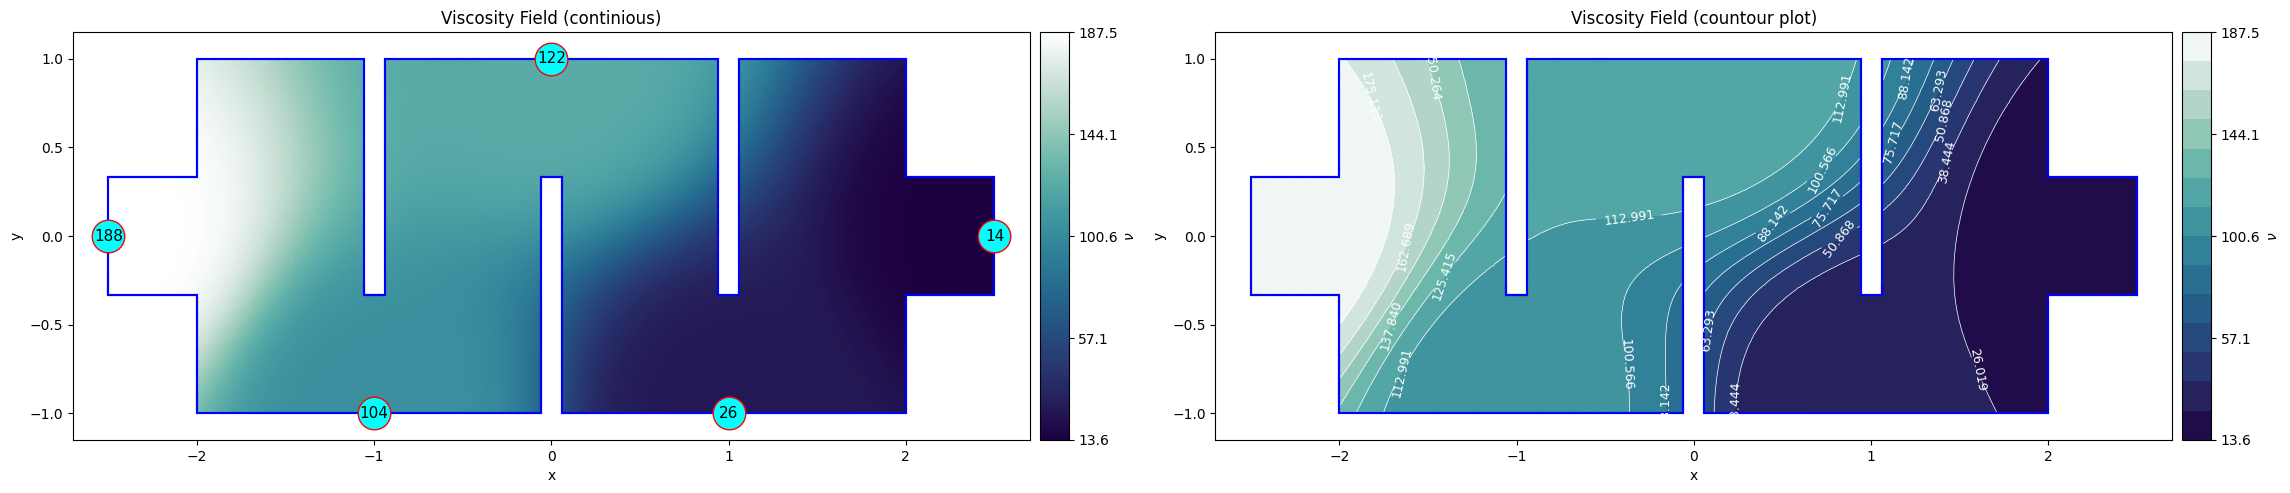

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Snapshot 9
Maximum absolute error : 8.527e-14
Relative L2 error      : 1.397e-16

Original viscosity, mu = [101.01440243  70.12686984 153.46389832  13.20484162 104.62377116]


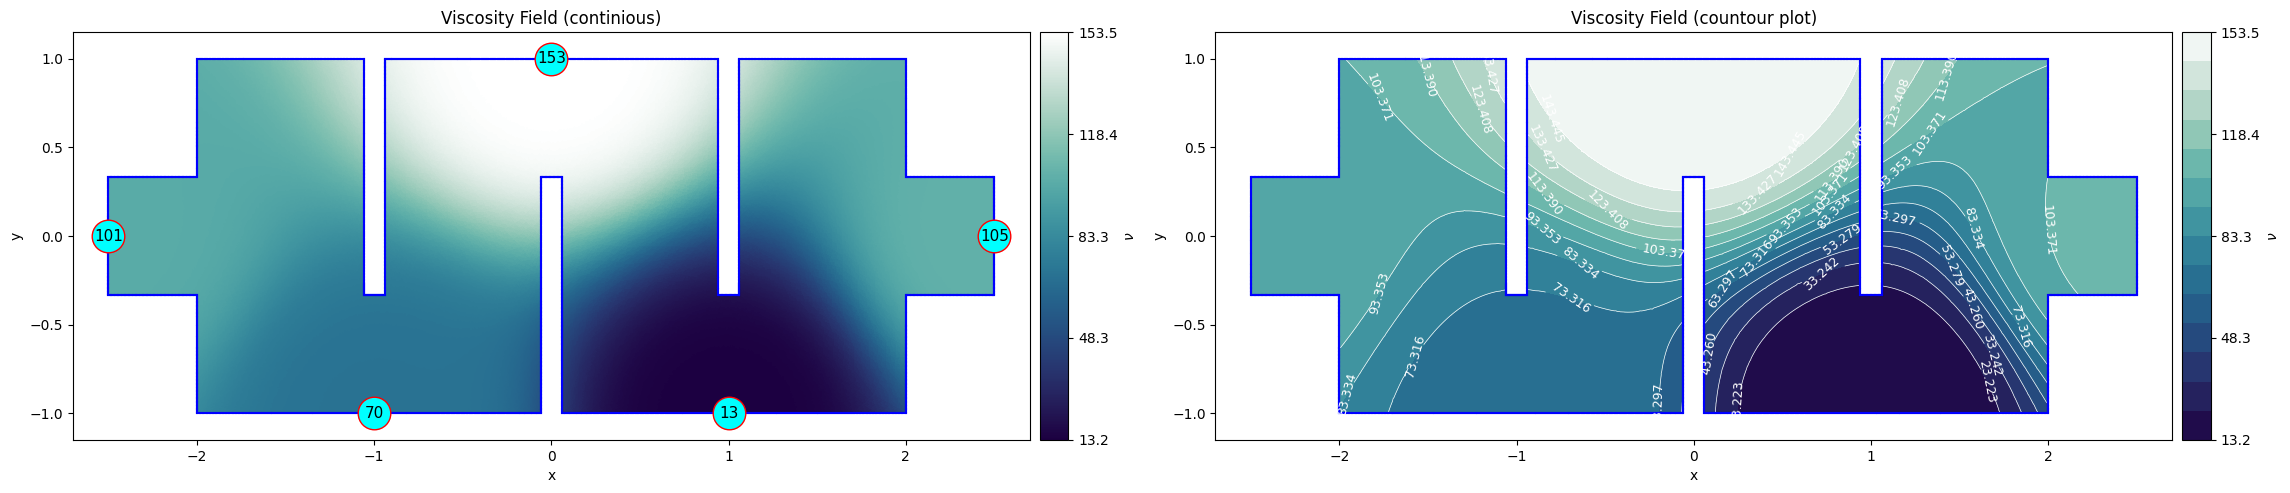


Reconstructed viscosity, mu = [101.01440243  70.12686984 153.46389832  13.20484162 104.62377116]


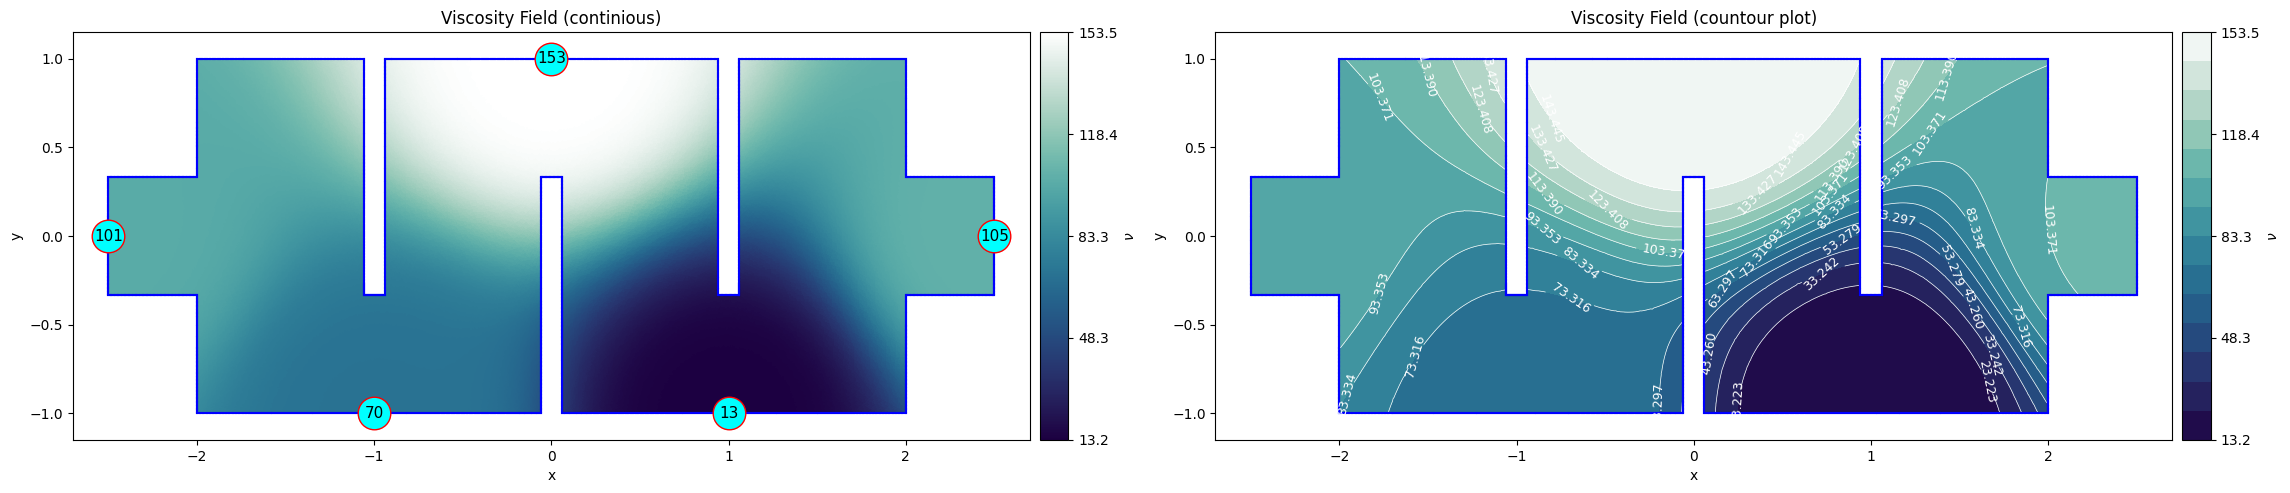

In [7]:
for snapshot_idx in viscosity_snapshot_indices:

    params_snapshot = parameters[snapshot_idx]
    v_original = v_t_snapshots[snapshot_idx]
    v_reconstructed = psi_field @ params_snapshot

    abs_error = np.max(np.abs(v_original - v_reconstructed))
    rel_error = np.linalg.norm(v_original - v_reconstructed) / np.linalg.norm(v_original)

    print("─" * 170)
    print(f"Snapshot {snapshot_idx}")
    print(f"Maximum absolute error : {abs_error:.3e}")
    print(f"Relative L2 error      : {rel_error:.3e}")

    nu_KNOTS = {
        "pts":  knots,
        "vals": params_snapshot
    }

    print(f"\nOriginal viscosity, mu = {params_snapshot}")
    plot_viscosity(p_fine, t_fine, e_fine, v_original, nu_KNOTS, 
                   n_levels=15, figsize=(23, 10), savetype="png")

    print(f"\nReconstructed viscosity, mu = {params_snapshot}")
    plot_viscosity(p_fine, t_fine, e_fine, v_reconstructed, nu_KNOTS, 
                      n_levels=15, figsize=(23, 10), savetype="png")

<div style="background-color: #bee7ff; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0;  color: #1e1a66">Downprojected Parameter Space (Sampled by LHS) via PCA:</h3>
</div>

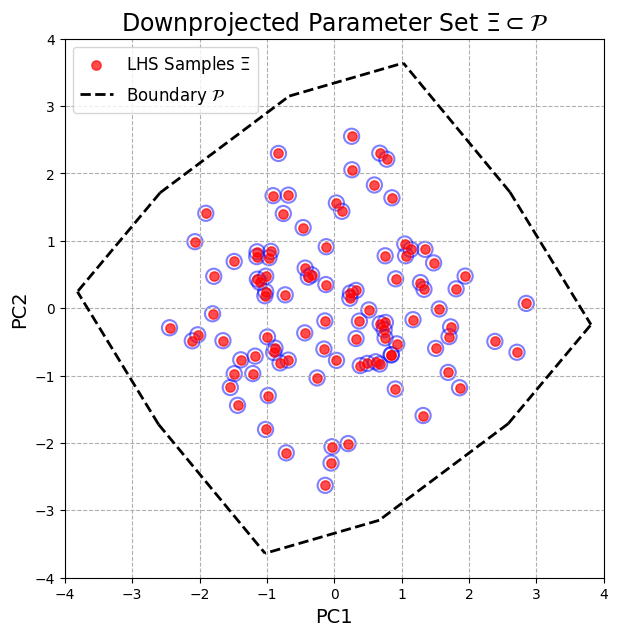

In [ ]:
# Data Downprojection __________________________________________________________________________________________
scaler = StandardScaler()
pca    = PCA(n_components=2)

scaled_parameters        = scaler.fit_transform(parameters)
downprojected_parameters = pca.fit_transform(scaled_parameters)
x_dp, y_dp = downprojected_parameters[:, 0], downprojected_parameters[:, 1]

# Hypercube [20 x 100]^5 Downprojection ________________________________________________________________________
bounds = [10, 200]
corners_5d = np.array(list(itertools.product(bounds, repeat=5)))
scaled_corners = scaler.transform(corners_5d)
downprojected_corners = pca.transform(scaled_corners)
hull = ConvexHull(downprojected_corners) # All the vertices of the hypercube are projected 
                                         # and the convex hull of them is computed.

# Plot _________________________________________________________________________________________________________
fig, ax = plt.subplots(figsize=(7,7))

ax.scatter(x_dp, y_dp, c='r', s=45, alpha=0.7, label='LHS Samples $\\Xi$', zorder=3)
ax.scatter(x_dp, y_dp, s=120, alpha=0.5, linewidths=1.5, facecolors='none', edgecolors='blue', zorder=1)
for i, simplex in enumerate(hull.simplices):
    if i == 0:
        ax.plot(downprojected_corners[simplex, 0], downprojected_corners[simplex, 1], 'k--', lw=2, zorder=2, label='Boundary $\\mathcal{P}$')
    else:
        ax.plot(downprojected_corners[simplex, 0], downprojected_corners[simplex, 1], 'k--', lw=2, zorder=2)

x_min = np.floor(min(x_dp.min(), downprojected_corners[:, 0].min()))
x_max = np.ceil(max(x_dp.max(), downprojected_corners[:, 0].max()))
y_min = np.floor(min(y_dp.min(), downprojected_corners[:, 1].min()))
y_max = np.ceil(max(y_dp.max(), downprojected_corners[:, 1].max()))

ax.set_xlim([x_min, x_max])
ax.set_ylim([y_min, y_max])
ax.set_aspect('equal')
ax.grid(True, linestyle='--', zorder = 0)

ax.set_title('Downprojected Parameter Set $\\Xi \\subset \\mathcal{P}$', fontsize=17)
ax.set_xlabel('PC1', fontsize=14)
ax.set_ylabel('PC2', fontsize=14)
ax.legend(loc='best', fontsize=12)

plt.savefig(f'Outputs/LHS_downprojected.png')
plt.show()

<div style="background-color: #bee7ff; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0;  color: #1e1a66">Supremizer Enrichment, Snapshot Homogenization:</h3>
</div>

### Supremizer Enrichment

$$X_u S_t = B_h^T S_p^T \quad \implies \quad S_t = X_u^{-1} B_h^T S_p^T$$

$$S_{\text{enriched}} = \begin{bmatrix} S_u \\ S_t^T \end{bmatrix}$$

$$\text{SVD}(S_{\text{enriched}}) \longrightarrow V_u$$

In [8]:
S_velocity = np.hstack([ux_snapshots, 
                        uy_snapshots])
S_pressure = p_snapshots

In [9]:
_, _, _, Xu, B_hT = compute_U_P_solution(p_fine, t_fine, e_fine,
                                         p_coarse, t_coarse, kinematic_viscosity=1, 
                                         return_matrices=True)

In [10]:
solve_Xu = spla.factorized(Xu.tocsc())

rhs_tensor = B_hT.dot(S_pressure.T)
S_t = solve_Xu(rhs_tensor)

In [11]:
print(f"Xu shape:                {Xu.shape}")
print(f"B_hT shape:              {B_hT.shape}")
print(f"S_t shape:               {S_t.shape}")

Xu shape:                (193634, 193634)
B_hT shape:              (193634, 24473)
S_t shape:               (193634, 100)


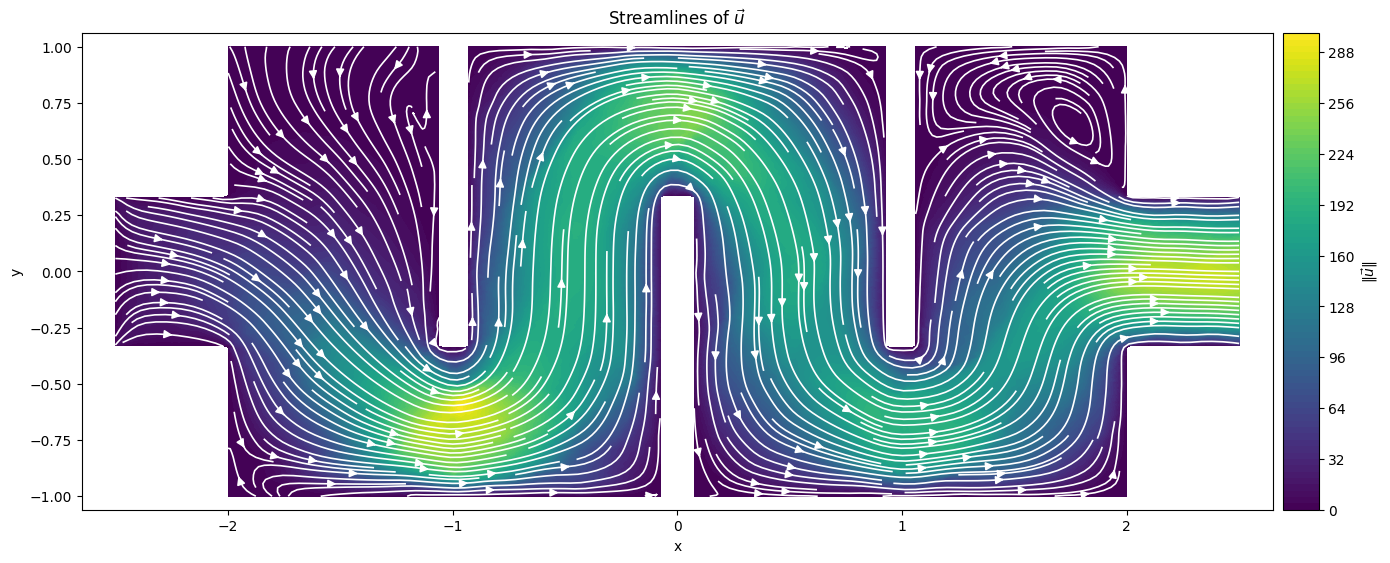

In [81]:
plot_streamlines(p_fine, t_fine, -S_t[:96817, 19], -S_t[96817:, 19])

### Boundary Lifting & Snapshot Homogenization

Separating inhomogeneous Dirichlet boundary conditions ($\mathbf{u}_{\text{l}}\vert{}_{\partial\Omega_D} = \mathbf{g}$) to construct a homogeneous reduced space ($\mathbf{u}_{\text{h}}\vert{}_{\partial\Omega_D} = \mathbf{0}$):

$$\mathbf{u}_{\text{f}} = \mathbf{u}_{\text{l}} + \mathbf{u}_{\text{h}} = \mathbf{u}_{\text{l}} + \sum_{i=1}^{r} u_i \boldsymbol{\phi}_i$$

In [13]:
eps  = 1e-10
Nv = p_fine.shape[0]
Np = p_coarse.shape[0]

xmin = p_fine[:, 0].min()
inlet_idx = np.where(np.abs(p_fine[:, 0] - xmin) < eps)[0]

inlet_velocity = 1.0                          # (same for all snapshots)
lf = np.zeros(2 * Nv)
lf[:Nv][inlet_idx] = inlet_velocity

S_velocity_homog = S_velocity - lf[None, :]   # subtracting lift from every snapshot row -> homogeneous u0

<div style="background-color: #bee7ff; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #1e1a66">POD Basis Extraction & Energy Truncation</h3>
</div>

Train/Test split:

In [14]:
test_idx  = 0
train_idx = np.arange(1, S_velocity.shape[0])

In [15]:
def pod_basis(S, energy:float=0.9999, name:str="",
              plot:bool=False,
              manual_selection:bool=False, k:int=5):
    
    _U, s, _ = np.linalg.svd(S.T, full_matrices=False)

    if manual_selection:
        return _U[:, :k]
    
    normalized_eigenvalues = np.cumsum(s**2) / np.sum(s**2)    
    _N = int(np.searchsorted(normalized_eigenvalues, energy) + 1)
    enery_true = normalized_eigenvalues[_N-1]
    print(f"[{name}] kept {_N}/{len(s)} modes, energy = {enery_true:.6f}")

    if plot:
        plt.figure(figsize=(7, 7))

        plt.plot(normalized_eigenvalues, 
                linestyle='-',
                marker='o', 
                markersize=3.5,
                color="#373eac",
                linewidth=1.5,
                label="Cumulative Energy")
        
        plt.axhline(y=energy,
                    color="green",
                    linestyle="--",
                    linewidth=1.2,
                    label=f"Target energy ({energy * 100}%)")
        
        plt.axhline(y=enery_true,
                    color="crimson",
                    linestyle="--",
                    linewidth=1.2,
                    label=f"Selected energy ({enery_true * 100:.4f}%)")

        plt.scatter(_N-1,
                    normalized_eigenvalues[_N - 1],
                    color="#39003A",
                    marker="x",
                    s=130,
                    linewidth=2.5,
                    zorder=5,
                    label=f"Selected {_N} modes")
        
        plt.title(f"POD Energy Spectrum — {name.capitalize()}", fontsize=12, weight="bold", pad=12)
        plt.xlabel("Snapshot / Mode Index ($i$)", fontsize=11)
        plt.ylabel("Cumulative Energy Ratio / $\\lambda_i / \\sum_i \\lambda_i$", fontsize=11)

        plt.xscale('symlog', linthresh=10)
        plt.xticks([0, 5, 10, 20, 40, 60, 80, 100], 
                   [0, 5, 10, 20, 40, 60, 80, 100])

        plt.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=15)
        plt.grid(True, which="both", ls="--", alpha=0.3)
        plt.savefig(f'Outputs/POD_Energy_Spectrum_{name}.png')
        plt.show()
    
    return _U[:, :_N]

[velocity (homogeneous)] kept 5/99 modes, energy = 0.999937


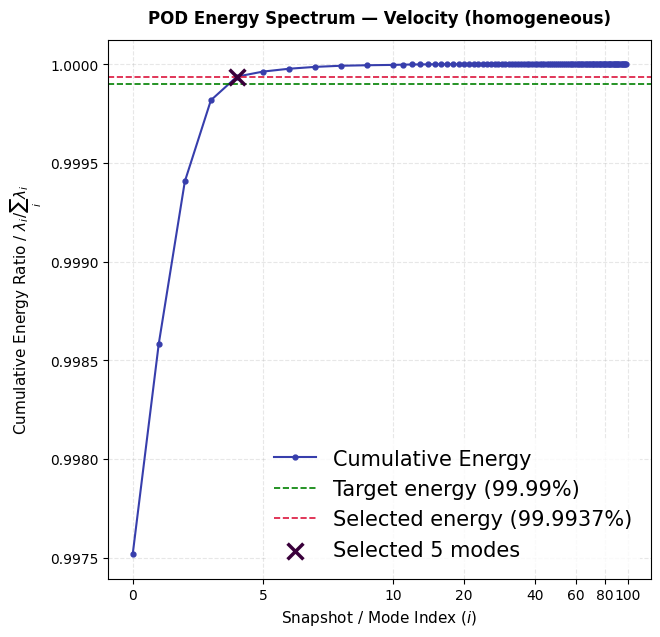

[supremizer] kept 6/99 modes, energy = 0.999933


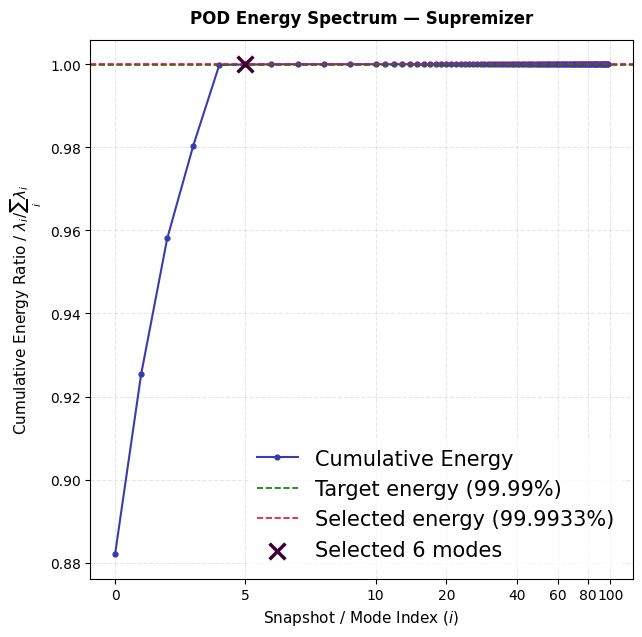

[pressure] kept 5/99 modes, energy = 0.999999


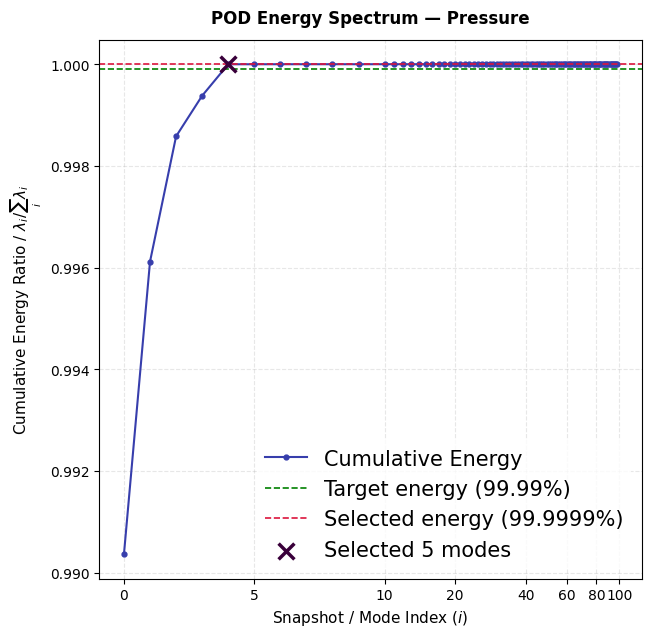

Vu shape: (193634, 11)   Vp shape: (24473, 5)


In [16]:
Vu_tilde = pod_basis(S_velocity_homog[train_idx], energy=0.9999, name="velocity (homogeneous)", plot=True)
Vs       = pod_basis(S_t.T[train_idx],            energy=0.9999, name="supremizer", plot=True)
Vp       = pod_basis(S_pressure[train_idx],       energy=0.9999, name="pressure", plot=True)

Vu = np.hstack([Vu_tilde, Vs])
print(f"Vu shape: {Vu.shape}   Vp shape: {Vp.shape}")

---

<div style="background-color: #bee7ff; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #1e1a66">Reduced Model Construction:</h3>
</div>

In [17]:
def solve_ROM(input_parameters, 
              Reduced_Affine_Operators, Velocity_basis, Reduced_divergence, Reduced_rhs, Reduced_Lifting_Vectors, lifting_f):
    
    Div_N = Reduced_divergence
    g_N   = Reduced_rhs

    # Online affine assembly
    Lap_N = sum((mu * X_i for mu, X_i in zip(input_parameters, Reduced_Affine_Operators)),
                np.zeros_like(Reduced_Affine_Operators[0]))
    
    f_N = sum(mu * f_i for mu, f_i in zip(input_parameters, Reduced_Lifting_Vectors))

    Nu_, Np_ = Lap_N.shape[0], Div_N.shape[0]

    K_cheap = np.block([[Lap_N, Div_N.T], 
                        [Div_N, np.zeros((Np_, Np_))]])
                    
    sol_N = np.linalg.solve(K_cheap, np.concatenate([np.ravel(f_N), 
                                                     np.ravel(g_N)]))
    u_N, p_N = sol_N[:Nu_], sol_N[Nu_:]
    u_red = Velocity_basis @ u_N + lifting_f       # (Adding the lift back)
    
    return u_red[:Nv], u_red[Nv:], Vp @ p_N

The discrete divergence matrix $B_h$ depends solely on the spatial mesh geometry, allowing it to be assembled once in the offline phase. Its reduced counterpart, $B_N = V_p^T B_h V_u$, is also precomputed offline to eliminate runtime projections. Because the viscosity field is linear, the high-dimensional viscous operator admits an exact affine decomposition $A(\boldsymbol{\mu}) = \sum \mu_i A_i$. Pre-projecting each parameter-independent base matrix offline gives $A_{N,i} = V_u^T A_i V_u$. In the online phase, the reduced stiffness matrix $A_N(\boldsymbol{\mu}) = \sum \mu_i A_{N,i}$ is constructed instantly via a simple scalar sum of small matrices. This structure achieves a true offline-online decomposition, making online evaluation time completely independent of the fine mesh size $N$.

### Offline Phase:

Lifting function $f$ and Affine operators $\{\mathbf{A}_i\}_{i=1}^5$ will be later multiplied with $\mu$

In [30]:
Reduced_Affine_Operators = []

for A_i in Affine_Operators:
    X_i = sp.block_diag([A_i, A_i]).tocsc()
    Reduced_Affine_Operators.append(
        Vu.T @ (X_i @ Vu)
        )

In [31]:
Reduced_lifting_vectors = []

for A_i in Affine_Operators:
    X_i = sp.block_diag([A_i, A_i]).tocsc()
    Reduced_lifting_vectors.append(
        -(Vu.T @ (X_i @ lf))
    )

The divergence matrix $\mathbf{B}$ is $\mu$ independent

In [32]:
Bx, By = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
Bh  = sp.hstack([Bx, By]).tocsc()

Div_N = Vp.T @ (Bh @ Vu)
g_N   = Vp.T @ (-(Bh @ lf))

### Online Phase:

In [21]:
ux_rom, uy_rom, p_rom = solve_ROM(parameters[test_idx],
                                  Reduced_Affine_Operators, Vu, Div_N, g_N, Reduced_lifting_vectors, lf)

ux_true, uy_true, p_true = ux_snapshots[test_idx], uy_snapshots[test_idx], p_snapshots[test_idx]

<div style="background-color: #bee7ff; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #1e1a66">Inspections and Tests:</h3>
</div>

In [22]:
Umag_true = np.sqrt(ux_true**2 + uy_true**2)
Umag_rom  = np.sqrt(ux_rom**2  + uy_rom**2)
abs_err_u = np.abs(Umag_rom - Umag_true)
abs_err_p = np.abs(p_rom - p_true)

rel_u = np.linalg.norm(Umag_rom - Umag_true) / np.linalg.norm(Umag_true)
rel_p = np.linalg.norm(p_rom - p_true) / np.linalg.norm(p_true)
print(f"Relative L2 error |U|: {rel_u:.3e}")
print(f"Relative L2 error  p : {rel_p:.3e}")


# tri_fine   = plt.matplotlib.tri.Triangulation(p_fine[:, 0],   p_fine[:, 1],   t_fine[:, :3])
# tri_coarse = plt.matplotlib.tri.Triangulation(p_coarse[:, 0], p_coarse[:, 1], t_coarse[:, :3])

# fig, axes = plt.subplots(2, 3, figsize=(20, 9))
# for ax, field, title, cmap in zip(axes[0], [Umag_true, Umag_rom, abs_err_u],
#                                    ["FOM |U|", "ROM |U|", "Abs. Error |U|"],
#                                    ['viridis', 'viridis', 'inferno']):
#     cf = ax.tricontourf(tri_fine, field, levels=20, cmap=cmap)
#     fig.colorbar(cf, ax=ax); ax.set_title(title); ax.set_aspect('equal')

# for ax, field, title, cmap in zip(axes[1], [p_true, p_rom, abs_err_p],
#                                    ["FOM p", "ROM p", "Abs. Error p"],
#                                    ['coolwarm', 'coolwarm', 'inferno']):
#     cf = ax.tricontourf(tri_coarse, field, levels=20, cmap=cmap)
#     fig.colorbar(cf, ax=ax); ax.set_title(title); ax.set_aspect('equal')

# plt.suptitle(f"ROM vs FOM — held-out snapshot {test_idx}  "
#              f"(rel. err |U|={rel_u:.2%}, p={rel_p:.2%})")
# plt.tight_layout()
# plt.show()

Relative L2 error |U|: 3.688e-03
Relative L2 error  p : 2.682e-04


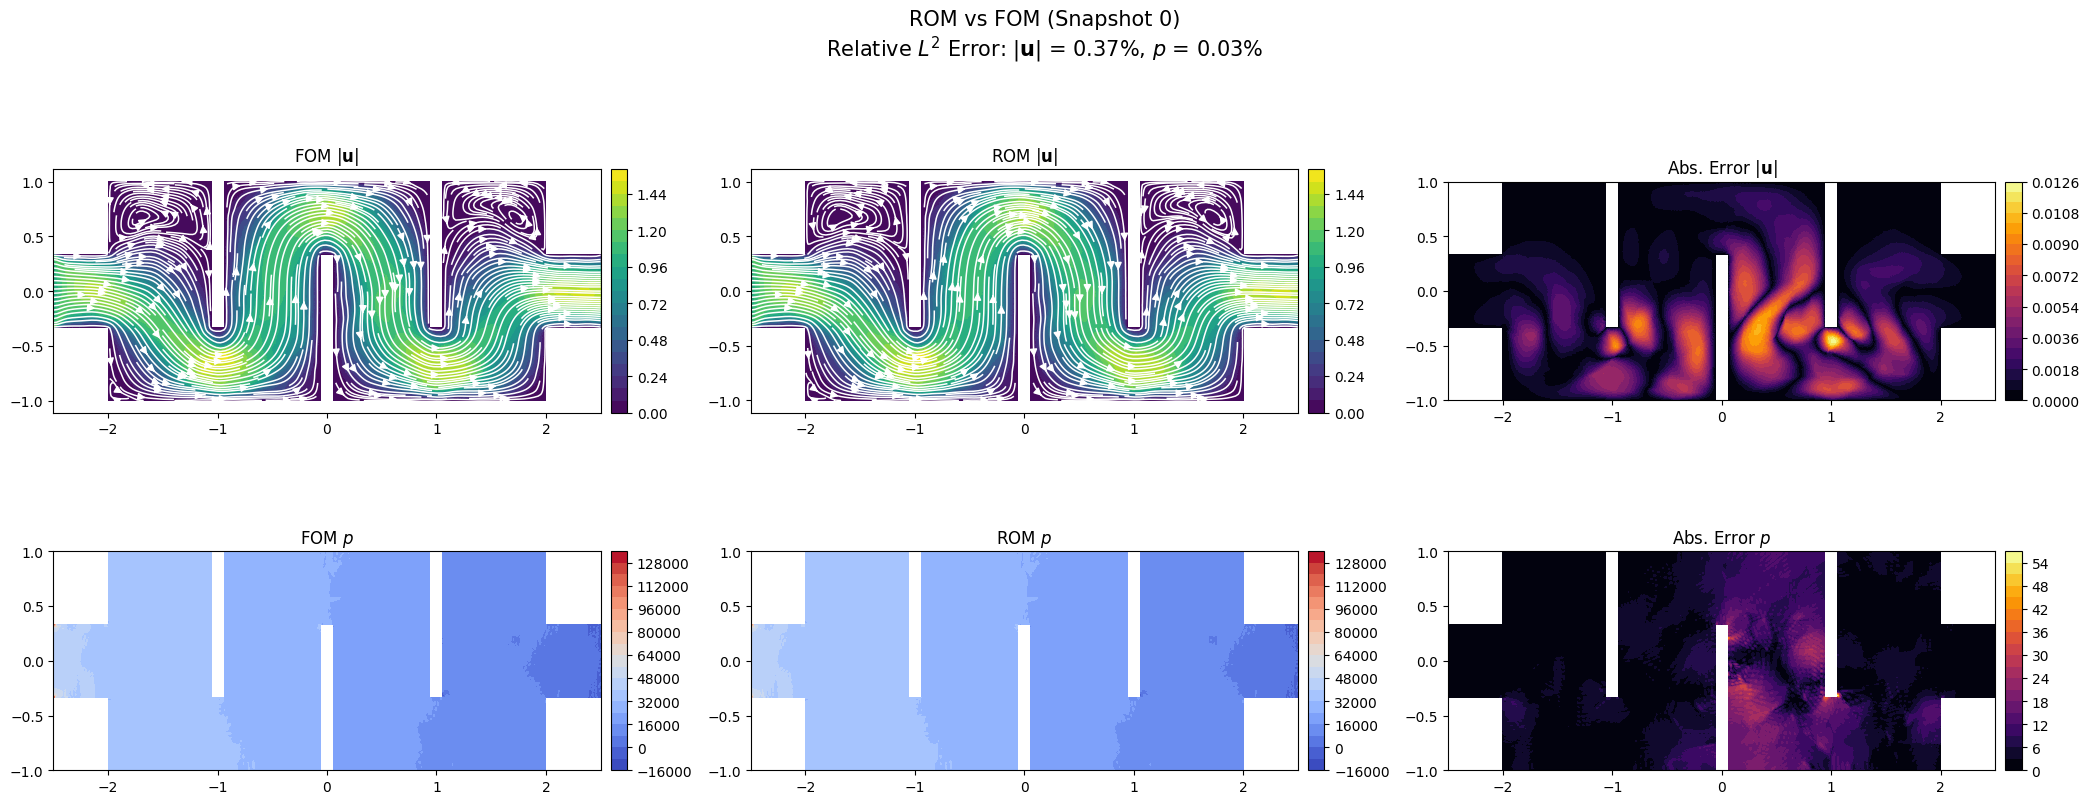

In [23]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import griddata
import matplotlib.tri as tri

tri_fine   = tri.Triangulation(p_fine[:, 0], p_fine[:, 1], t_fine[:, :3])
tri_coarse = tri.Triangulation(p_coarse[:, 0], p_coarse[:, 1], t_coarse[:, :3])

# ------------------------------------------------------------------
# Streamline grid
# ------------------------------------------------------------------

nx, ny = 300, 300

xi = np.linspace(p_fine[:,0].min(), p_fine[:,0].max(), nx)
yi = np.linspace(p_fine[:,1].min(), p_fine[:,1].max(), ny)
X, Y = np.meshgrid(xi, yi)

triang = tri.Triangulation(
    p_fine[:,0],
    p_fine[:,1],
    t_fine[:, :3]
)

trifinder = triang.get_trifinder()
mask = (trifinder(X, Y) == -1)

def interpolate_velocity(ux, uy):
    U = griddata((p_fine[:,0], p_fine[:,1]), ux, (X, Y), method="cubic")
    V = griddata((p_fine[:,0], p_fine[:,1]), uy, (X, Y), method="cubic")

    U = np.ma.array(U, mask=mask)
    V = np.ma.array(V, mask=mask)

    return U, V

U_true, V_true = interpolate_velocity(ux_true, uy_true)
U_rom,  V_rom  = interpolate_velocity(ux_rom,  uy_rom)

# ------------------------------------------------------------------
# Common colour scales
# ------------------------------------------------------------------

vel_min = min(Umag_true.min(), Umag_rom.min())
vel_max = max(Umag_true.max(), Umag_rom.max())

p_min = min(p_true.min(), p_rom.min())
p_max = max(p_true.max(), p_rom.max())

fig, axes = plt.subplots(2, 3, figsize=(21, 9))

# ==============================================================
# Velocity magnitude
# ==============================================================

velocity_fields = [
    (Umag_true, "FOM $|\\mathbf{u}|$", U_true, V_true),
    (Umag_rom,  "ROM $|\\mathbf{u}|$", U_rom,  V_rom),
]

for ax, (field, title, U, V) in zip(axes[0, :2], velocity_fields):

    cf = ax.tricontourf(
        tri_fine,
        field,
        levels=20,
        cmap="viridis",
        vmin=vel_min,
        vmax=vel_max
    )

    ax.streamplot(
        X,
        Y,
        U,
        V,
        density=3.5,
        color="white",
        linewidth=1.1,
        arrowsize=1.1
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1)
    plt.colorbar(cf, cax=cax)

    ax.set_title(title)
    ax.set_aspect("equal")

# Velocity error

cf = axes[0,2].tricontourf(
    tri_fine,
    abs_err_u,
    levels=20,
    cmap="inferno"
)

divider = make_axes_locatable(axes[0,2])
cax = divider.append_axes("right", size="3%", pad=0.1)
plt.colorbar(cf, cax=cax)

axes[0,2].set_title("Abs. Error $|\\mathbf{u}|$")
axes[0,2].set_aspect("equal")

# ==============================================================
# Pressure
# ==============================================================

pressure_fields = [
    (p_true, "FOM $p$"),
    (p_rom,  "ROM $p$")
]

for ax, (field, title) in zip(axes[1, :2], pressure_fields):

    cf = ax.tricontourf(
        tri_coarse,
        field,
        levels=20,
        cmap="coolwarm",
        vmin=p_min,
        vmax=p_max
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1)
    plt.colorbar(cf, cax=cax)

    ax.set_title(title)
    ax.set_aspect("equal")

# Pressure error

cf = axes[1,2].tricontourf(
    tri_coarse,
    abs_err_p,
    levels=20,
    cmap="inferno"
)

divider = make_axes_locatable(axes[1,2])
cax = divider.append_axes("right", size="3%", pad=0.1)
plt.colorbar(cf, cax=cax)

axes[1,2].set_title("Abs. Error $p$")
axes[1,2].set_aspect("equal")

plt.suptitle(
    f"ROM vs FOM (Snapshot {test_idx})\n"
    f"Relative $L^2$ Error: "
    f"$|\\mathbf{{u}}|$ = {rel_u:.2%}, "
    f"$p$ = {rel_p:.2%}",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Absolutely new parameter set:

In [24]:
# mu_unseen = [5, 201, 1, 9, 230]
mu_unseen = [99, 19, 199, 30, 133]

is_in_training = (parameters == mu_unseen).all(axis=1).any()
print(f"mu in parameters: {is_in_training}")

mu in parameters: False


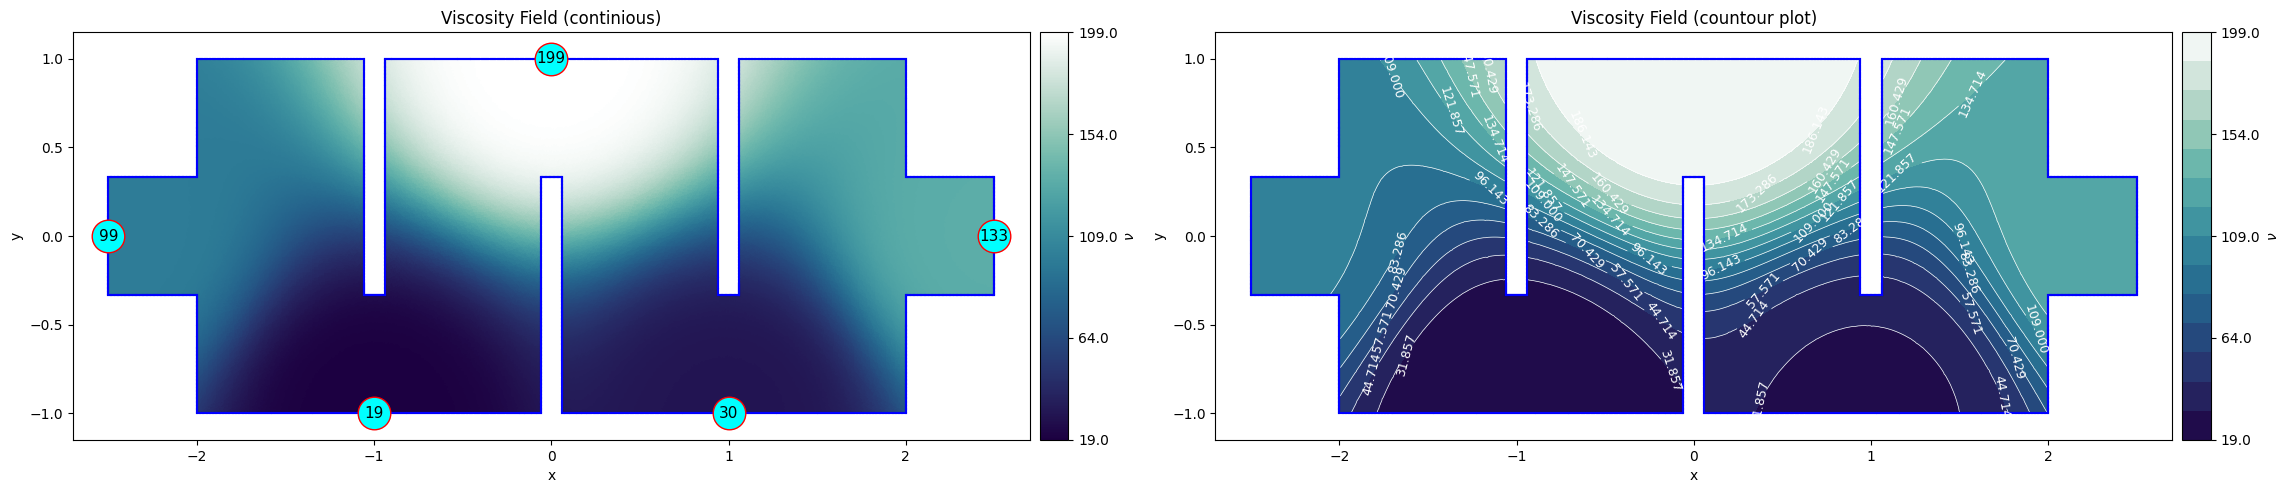

In [25]:
kinematic_viscosity = psi_field @ mu_unseen

nu_KNOTS = {
        "pts":  knots,
        "vals": mu_unseen
    }

plot_viscosity(p_fine, t_fine, e_fine, kinematic_viscosity, nu_KNOTS, 
               n_levels=15, figsize=(23, 10), savetype="png")

In [26]:
ux_true, uy_true, p_true = compute_U_P_solution(p_fine, t_fine, e_fine,
                                                p_coarse, t_coarse, 1, kinematic_viscosity)

In [27]:
ux_rom, uy_rom, p_rom = solve_ROM(mu_unseen,
                                  Reduced_Affine_Operators, Vu, Div_N, g_N, Reduced_lifting_vectors, lf)

Relative L2 error |U|: 7.945e-03
Relative L2 error  p : 1.161e-03


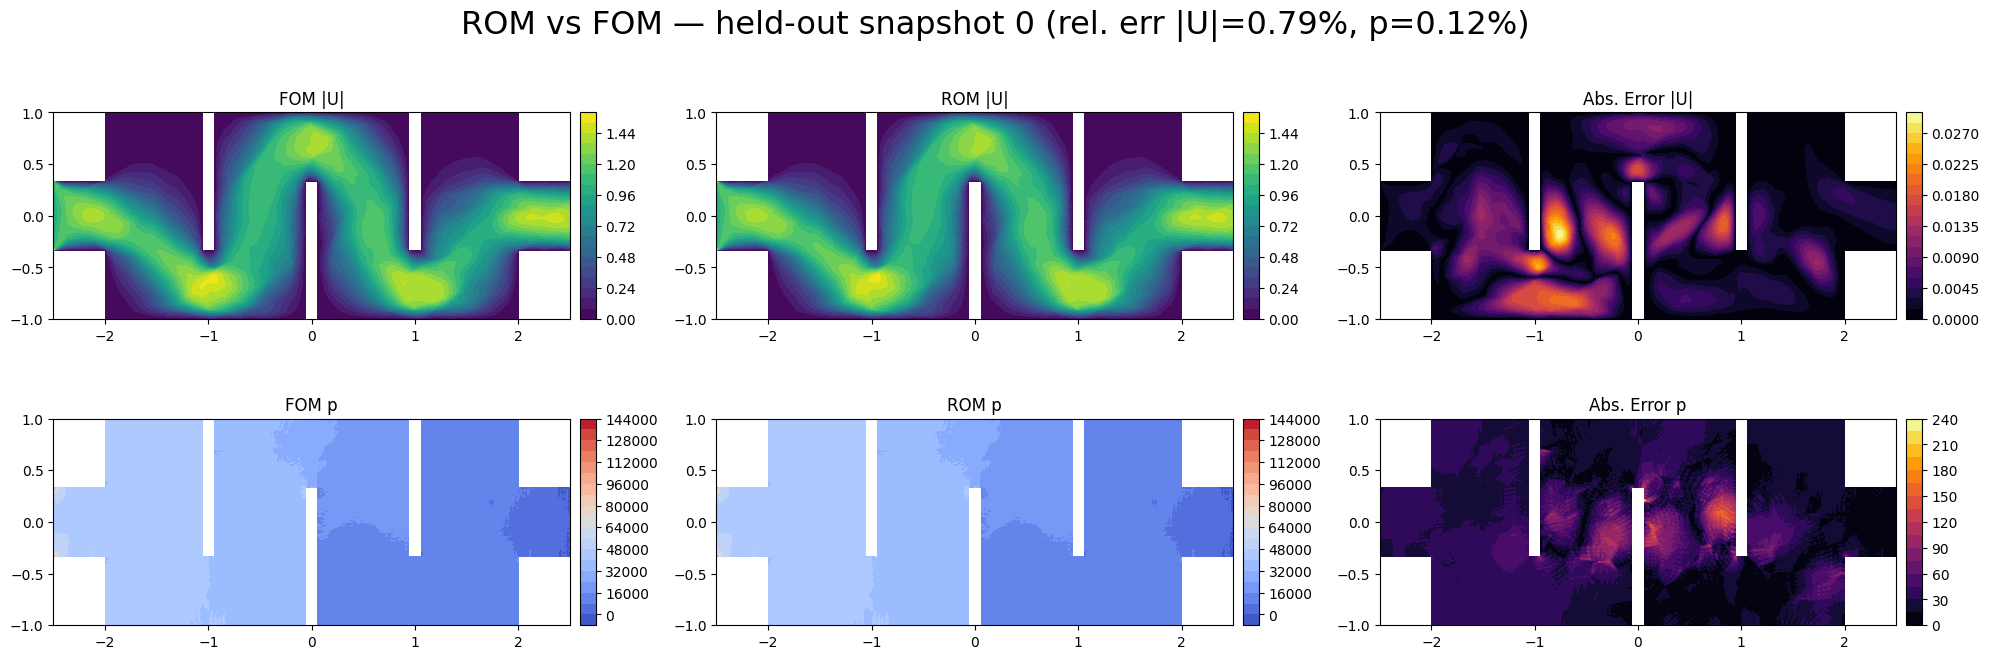

In [28]:
Umag_true = np.sqrt(ux_true**2 + uy_true**2)
Umag_rom  = np.sqrt(ux_rom**2  + uy_rom**2)
abs_err_u = np.abs(Umag_rom - Umag_true)
abs_err_p = np.abs(p_rom - p_true)

rel_u = np.linalg.norm(Umag_rom - Umag_true) / np.linalg.norm(Umag_true)
rel_p = np.linalg.norm(p_rom - p_true) / np.linalg.norm(p_true)
print(f"Relative L2 error |U|: {rel_u:.3e}")
print(f"Relative L2 error  p : {rel_p:.3e}")



tri_fine   = plt.matplotlib.tri.Triangulation(p_fine[:, 0],   p_fine[:, 1],   t_fine[:, :3])
tri_coarse = plt.matplotlib.tri.Triangulation(p_coarse[:, 0], p_coarse[:, 1], t_coarse[:, :3])

fig, axes = plt.subplots(2, 3, figsize=(20, 7))

for ax, field, title, cmap in zip(
    axes[0],
    [Umag_true, Umag_rom, abs_err_u],
    ["FOM |U|", "ROM |U|", "Abs. Error |U|"],
    ['viridis', 'viridis', 'inferno']
):
    cf = ax.tricontourf(tri_fine, field, levels=20, cmap=cmap)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1)
    fig.colorbar(cf, cax=cax)
    ax.set_title(title)
    ax.set_aspect('equal')

for ax, field, title, cmap in zip(
    axes[1],
    [p_true, p_rom, abs_err_p],
    ["FOM p", "ROM p", "Abs. Error p"],
    ['coolwarm', 'coolwarm', 'inferno']
):
    cf = ax.tricontourf(tri_coarse, field, levels=20, cmap=cmap)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1)
    fig.colorbar(cf, cax=cax)
    ax.set_title(title)
    ax.set_aspect('equal')

plt.suptitle(
    f"ROM vs FOM — held-out snapshot {test_idx} "
    f"(rel. err |U|={rel_u:.2%}, p={rel_p:.2%})", fontsize = 23
)
plt.tight_layout()
plt.show()

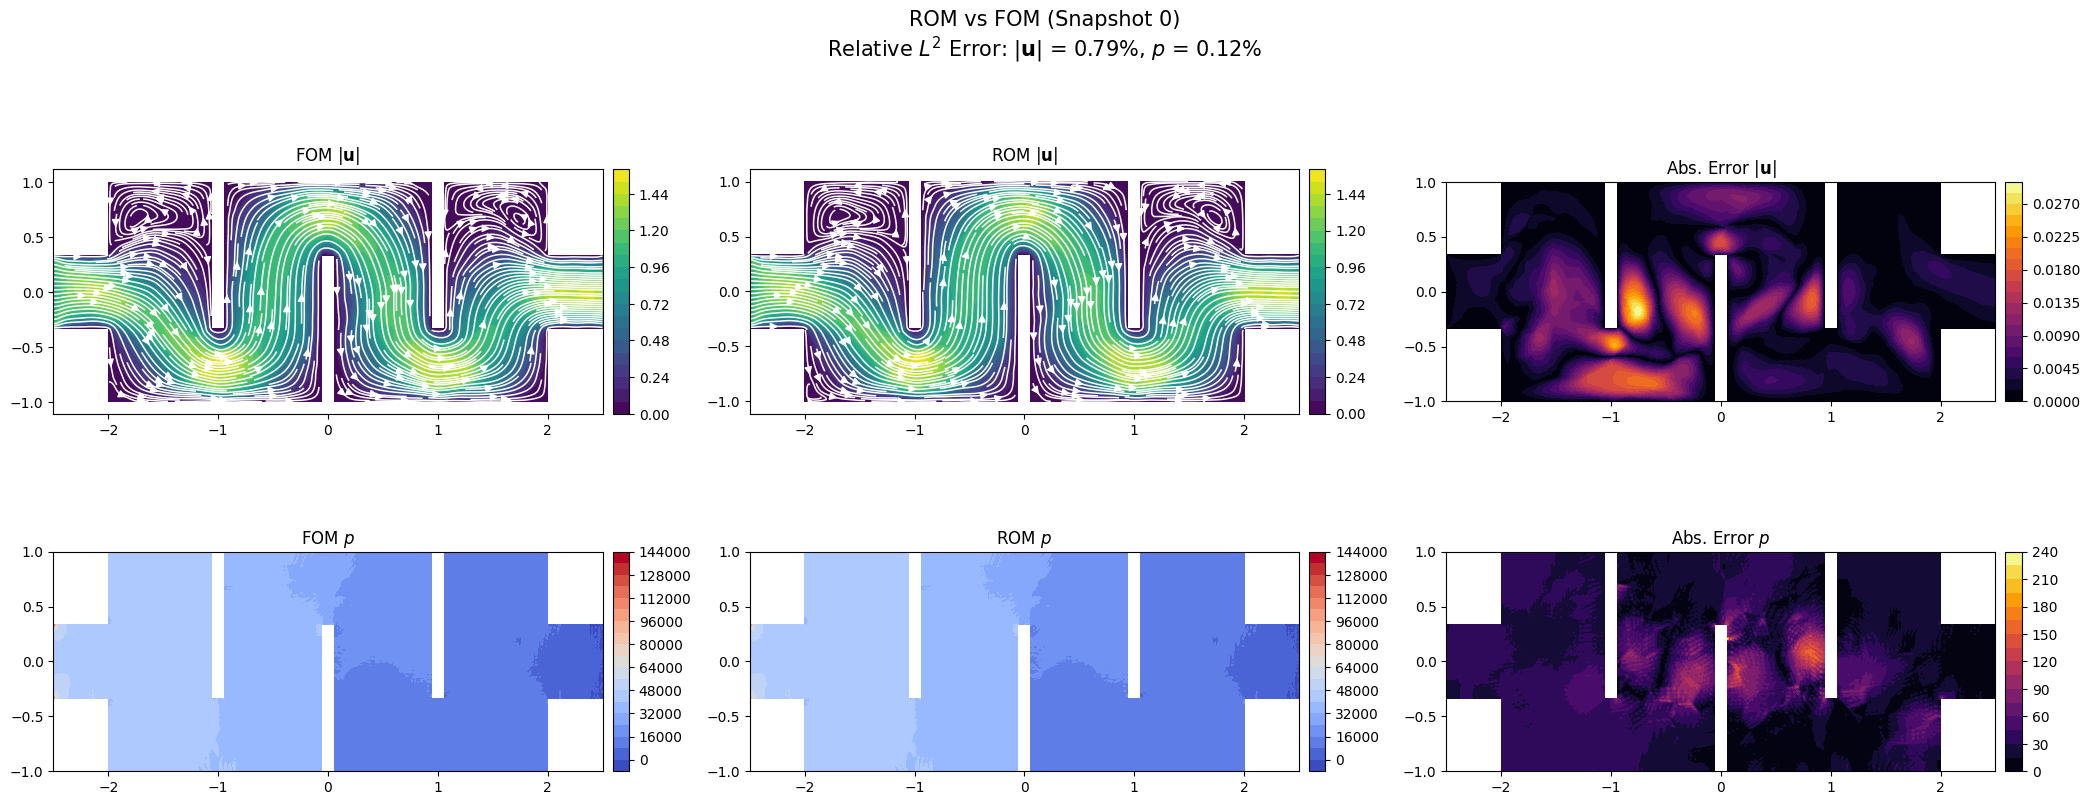

In [29]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import griddata
import matplotlib.tri as tri

tri_fine   = tri.Triangulation(p_fine[:, 0], p_fine[:, 1], t_fine[:, :3])
tri_coarse = tri.Triangulation(p_coarse[:, 0], p_coarse[:, 1], t_coarse[:, :3])

# ------------------------------------------------------------------
# Streamline grid
# ------------------------------------------------------------------

nx, ny = 300, 300

xi = np.linspace(p_fine[:,0].min(), p_fine[:,0].max(), nx)
yi = np.linspace(p_fine[:,1].min(), p_fine[:,1].max(), ny)
X, Y = np.meshgrid(xi, yi)

triang = tri.Triangulation(
    p_fine[:,0],
    p_fine[:,1],
    t_fine[:, :3]
)

trifinder = triang.get_trifinder()
mask = (trifinder(X, Y) == -1)

def interpolate_velocity(ux, uy):
    U = griddata((p_fine[:,0], p_fine[:,1]), ux, (X, Y), method="cubic")
    V = griddata((p_fine[:,0], p_fine[:,1]), uy, (X, Y), method="cubic")

    U = np.ma.array(U, mask=mask)
    V = np.ma.array(V, mask=mask)

    return U, V

U_true, V_true = interpolate_velocity(ux_true, uy_true)
U_rom,  V_rom  = interpolate_velocity(ux_rom,  uy_rom)

# ------------------------------------------------------------------
# Common colour scales
# ------------------------------------------------------------------

vel_min = min(Umag_true.min(), Umag_rom.min())
vel_max = max(Umag_true.max(), Umag_rom.max())

p_min = min(p_true.min(), p_rom.min())
p_max = max(p_true.max(), p_rom.max())

fig, axes = plt.subplots(2, 3, figsize=(21, 9))

# ==============================================================
# Velocity magnitude
# ==============================================================

velocity_fields = [
    (Umag_true, "FOM $|\\mathbf{u}|$", U_true, V_true),
    (Umag_rom,  "ROM $|\\mathbf{u}|$", U_rom,  V_rom),
]

for ax, (field, title, U, V) in zip(axes[0, :2], velocity_fields):

    cf = ax.tricontourf(
        tri_fine,
        field,
        levels=20,
        cmap="viridis",
        vmin=vel_min,
        vmax=vel_max
    )

    ax.streamplot(
        X,
        Y,
        U,
        V,
        density=3.5,
        color="white",
        linewidth=1.1,
        arrowsize=1.1
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1)
    plt.colorbar(cf, cax=cax)

    ax.set_title(title)
    ax.set_aspect("equal")

# Velocity error

cf = axes[0,2].tricontourf(
    tri_fine,
    abs_err_u,
    levels=20,
    cmap="inferno"
)

divider = make_axes_locatable(axes[0,2])
cax = divider.append_axes("right", size="3%", pad=0.1)
plt.colorbar(cf, cax=cax)

axes[0,2].set_title("Abs. Error $|\\mathbf{u}|$")
axes[0,2].set_aspect("equal")

# ==============================================================
# Pressure
# ==============================================================

pressure_fields = [
    (p_true, "FOM $p$"),
    (p_rom,  "ROM $p$")
]

for ax, (field, title) in zip(axes[1, :2], pressure_fields):

    cf = ax.tricontourf(
        tri_coarse,
        field,
        levels=20,
        cmap="coolwarm",
        vmin=p_min,
        vmax=p_max
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1)
    plt.colorbar(cf, cax=cax)

    ax.set_title(title)
    ax.set_aspect("equal")

# Pressure error

cf = axes[1,2].tricontourf(
    tri_coarse,
    abs_err_p,
    levels=20,
    cmap="inferno"
)

divider = make_axes_locatable(axes[1,2])
cax = divider.append_axes("right", size="3%", pad=0.1)
plt.colorbar(cf, cax=cax)

axes[1,2].set_title("Abs. Error $p$")
axes[1,2].set_aspect("equal")

plt.suptitle(
    f"ROM vs FOM (Snapshot {test_idx})\n"
    f"Relative $L^2$ Error: "
    f"$|\\mathbf{{u}}|$ = {rel_u:.2%}, "
    f"$p$ = {rel_p:.2%}",
    fontsize=15
)

plt.tight_layout()
plt.show()